# Brazilian E-Commerce Analysis (Olist)
## Objective
Analyze Olist's e-commerce data to understand:
- Revenue trends
- Customer behavior
- Product performance
- Geographic sales patterns

The goal is to generate business insights and build a Power BI dashboard.

In [1]:
import pandas as pd
print("Pandas loaded")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Pandas loaded


### Dataset Overview

In [2]:
customers = pd.read_csv("../data/olist_customers_dataset.csv/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv/olist_order_reviews_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv/olist_order_items_dataset.csv")
geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv/olist_geolocation_dataset.csv")
category_translation = pd.read_csv("../data/product_category_name_translation.csv")

In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [4]:
orders.head()
orders.info()
orders.isnull().sum()
orders.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


np.int64(0)

In [5]:
customers.info()
customers.isnull().sum()
customers.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


np.int64(0)

In [6]:
payments.info()
payments.isnull().sum()
payments.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


np.int64(0)

Initial data quality checks were performed to understand the dataset structure. Comprehensive cleaning and transformation were previously completed in Power BI before analysis.

### Sales Analysis

In [7]:
sales_df = orders.merge(
    payments,
    on="order_id",
    how="inner"
)

In [8]:
total_revenue = sales_df["payment_value"].sum()
total_orders = sales_df["order_id"].nunique()
aov = total_revenue / total_orders
unique_customers = sales_df["customer_id"].nunique()
print(f"Revenue: {total_revenue:,.2f}")
print(f"Orders: {total_orders:,}")
print(f"Customers: {unique_customers:,}")
print(f"AOV: {aov:.2f}")

Revenue: 16,008,872.12
Orders: 99,440
Customers: 99,440
AOV: 160.99


In [9]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
sales_df["year_month"] = (
    sales_df["order_purchase_timestamp"]
    .dt.to_period("M")
)
monthly_revenue = (
    sales_df.groupby("year_month")
    ["payment_value"]
    .sum()
    .reset_index()
)

### Monthly Revenue Trend

This analysis examines how revenue changed over time and identifies periods of high and low sales activity.

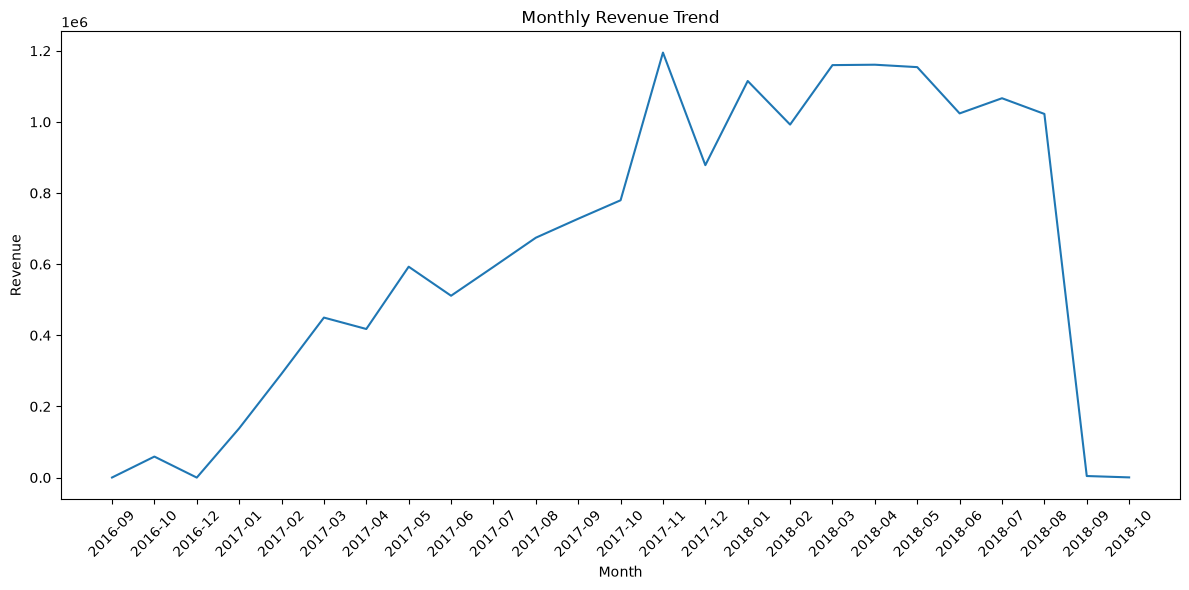

In [10]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_revenue["year_month"].astype(str),
    monthly_revenue["payment_value"]
)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue.png')
plt.show()

### Monthly Revenue Trend Insights

- Monthly revenue exhibited a strong upward trend from early 2017 through mid-2018, indicating sustained business growth and increasing customer demand.

- Revenue peaked in November 2017 at approximately 1.2 million, likely driven by seasonal shopping activity and promotional events such as Black Friday.

- In November 2017, revenue remained consistently high through much of 2018, suggesting that the business was able to maintain its growth momentum.


In [11]:
monthly_revenue["growth_rate"] = (
    monthly_revenue["payment_value"]
    .pct_change() * 100
)
monthly_revenue.head()

,year_month,payment_value,growth_rate
0,2016-09,252.24,NaN
1,2016-10,59090.48,23326.292420
2,2016-12,19.62,-99.966797
3,2017-01,138488.04,705751.376147
4,2017-02,291908.01,110.782108


In [12]:
monthly_revenue.sort_values(
    by="growth_rate",
    ascending=False
).head()

,year_month,payment_value,growth_rate
3,2017-01,138488.04,705751.376147
1,2016-10,59090.48,23326.292420
4,2017-02,291908.01,110.782108
5,2017-03,449863.60,54.111427
13,2017-11,1194882.80,53.253392


- January 2017 recorded the highest month-over-month revenue growth rate, indicating rapid early-stage expansion of the platform.

- However, November 2017 generated the highest absolute revenue (~1.2M), making it the strongest revenue-performing month in the dataset.

- This suggests that while the business experienced its fastest relative growth in early 2017, its largest commercial impact occurred during the November 2017 shopping season.

In [13]:
monthly_orders = (
    sales_df.groupby("year_month")["order_id"]
    .nunique()
    .reset_index()
)
monthly_orders.head()

,year_month,order_id
0,2016-09,3
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


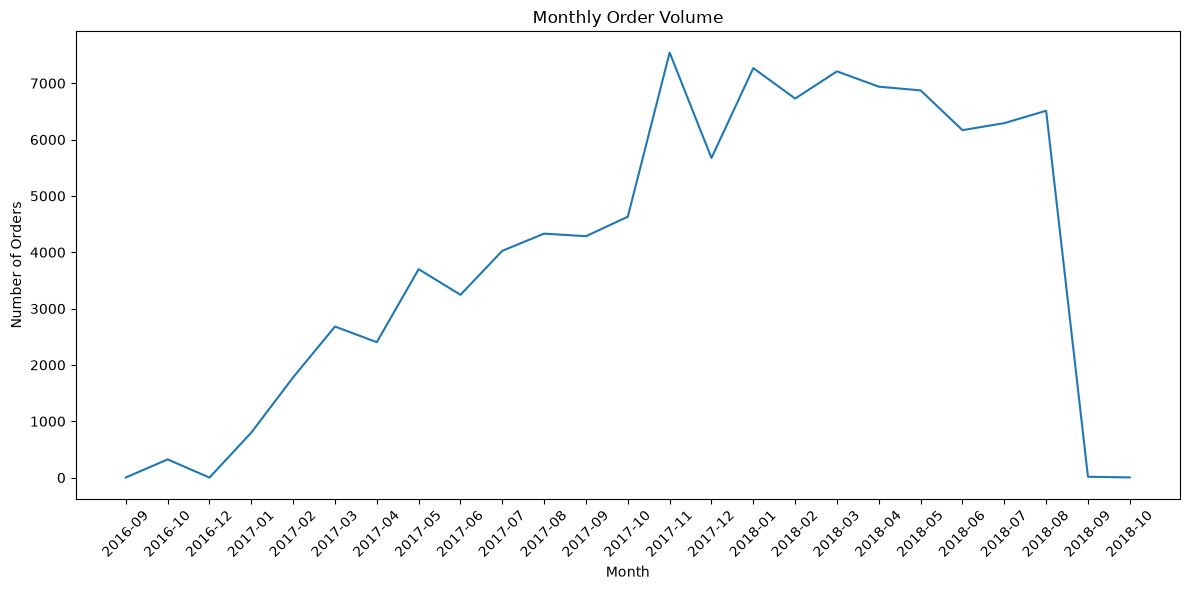

In [14]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_orders["year_month"].astype(str),
    monthly_orders["order_id"]
)
plt.xticks(rotation=45)
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig('../visuals/monthly_order_volume.png')
plt.show()

### Revenue and Order Trends

- November 2017 recorded both the highest revenue and the highest order volume, indicating a significant demand surge during this period.

- The surge is likely associated with seasonal shopping events such as Black Friday, which drove a substantial increase in customer purchases.

- While November 2017 remained the peak month, January 2018 and March 2018 recorded order volumes that were relatively close to the November peak.

- This suggests that the increase in demand was not a one-time event. The platform was able to sustain a high transaction volume into 2018, indicating continued business growth and customer adoption.


In [15]:
monthly_aov = (
    sales_df.groupby("year_month")
    .agg({
        "payment_value": "sum",
        "order_id": "nunique"
    })
    .reset_index()
)
monthly_aov["aov"] = (
    monthly_aov["payment_value"]
    / monthly_aov["order_id"]
)
monthly_aov.head()

,year_month,payment_value,order_id,aov
0,2016-09,252.24,3,84.080000
1,2016-10,59090.48,324,182.378025
2,2016-12,19.62,1,19.620000
3,2017-01,138488.04,800,173.110050
4,2017-02,291908.01,1780,163.993264


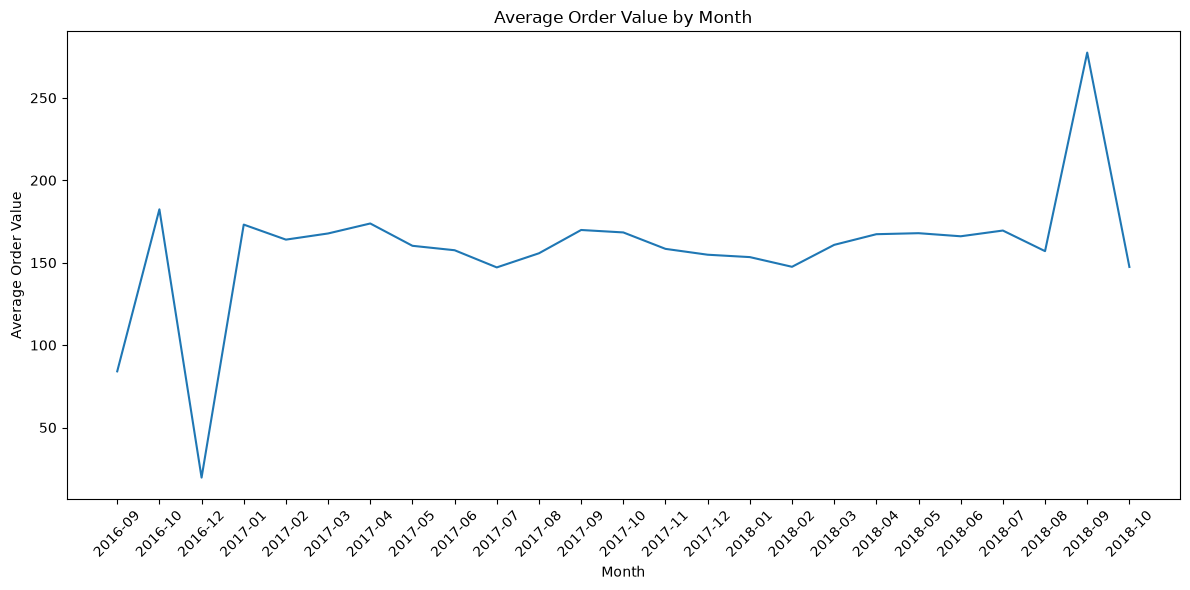

In [16]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_aov["year_month"].astype(str),
    monthly_aov["aov"]
)
plt.xticks(rotation=45)
plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.savefig('../visuals/monthly_aov.png')
plt.show()

- Revenue and order volume generally moved together throughout the period, implying that revenue growth was primarily driven by increasing customer demand rather than drastic changes in average order value.

### Product Analysis

In [17]:
product_sales = (
    order_items
        .merge(products, on="product_id",how = "left")
        .merge(category_translation, on="product_category_name", how="left")
)

In [18]:
# revenue by category
category_revenue = (
    product_sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_revenue.head(10)

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


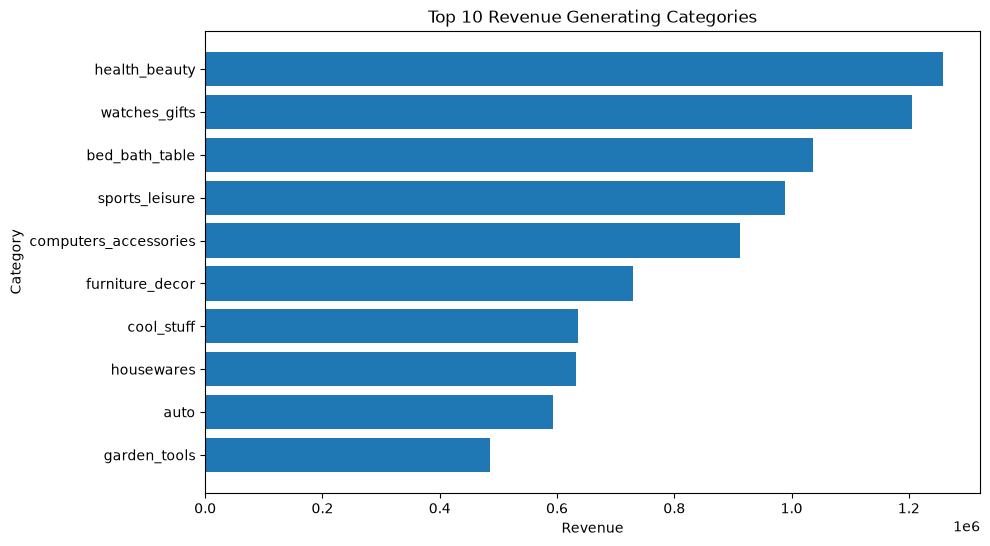

In [19]:
# top 10 categories revenue
top10_revenue = category_revenue.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10_revenue["product_category_name_english"],
    top10_revenue["price"]
)
plt.title("Top 10 Revenue Generating Categories")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.savefig('../visuals/top10_revenue_category.png')
plt.show()

In [20]:
# units sold by category
category_volume = (
    product_sales
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="units_sold")
)
category_volume.head(10)

,product_category_name_english,units_sold
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


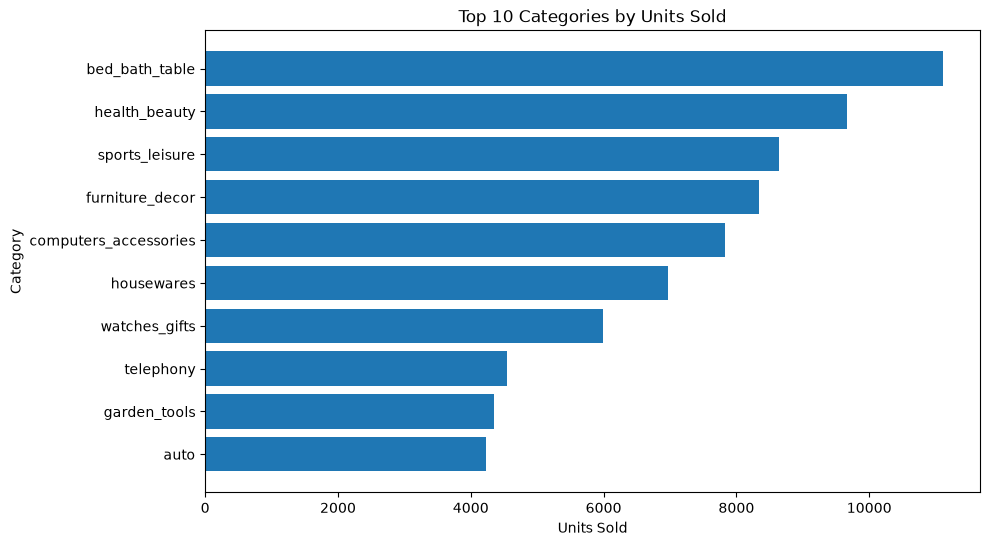

In [21]:
top10_volume = category_volume.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10_volume["product_category_name_english"],
    top10_volume["units_sold"]
)
plt.title("Top 10 Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Category")
plt.gca().invert_yaxis()
plt.savefig('../visuals/top10_category_by_unit.png')
plt.show()

In [22]:
# Average Product Price by Category
avg_price = (
    product_sales
    .groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
avg_price.head(10)

,product_category_name_english,price
0,computers,1098.340542
1,small_appliances_home_oven_and_coffee,624.285658
2,home_appliances_2,476.124958
3,agro_industry_and_commerce,342.124858
4,musical_instruments,281.616000
5,small_appliances,280.778468
6,fixed_telephony,225.693182
7,construction_tools_safety,208.992371
8,watches_gifts,201.135984
9,air_conditioning,185.269226


### Product Category Insights

- Bed Bath Table and Health Beauty emerged as the highest-volume product categories. These categories also generated substantial revenue, indicating that they are core business categories that drive both customer demand and overall platform revenue.

- The strong performance of these categories suggests that they have broad customer appeal and play a significant role in sustaining transaction volume on the platform.

- Watches & Gifts ranked among the top revenue-generating categories despite not being one of the highest-volume categories.

- The category also did not rank among the highest average-priced categories, suggesting that its strong revenue performance is driven by a balanced combination of sales volume and product pricing.

- This highlights that high revenue on the platform is not exclusively driven by either premium pricing or high transaction volume, but can also result from categories that perform well across both dimensions.

In [23]:
category_revenue["revenue_share"] = (
    category_revenue["price"]
    / category_revenue["price"].sum()
) * 100
category_revenue.head(10)

,product_category_name_english,price,revenue_share
0,health_beauty,1258681.34,9.388524
1,watches_gifts,1205005.68,8.988157
2,bed_bath_table,1036988.68,7.734915
3,sports_leisure,988048.97,7.369873
4,computers_accessories,911954.32,6.802282
5,furniture_decor,729762.49,5.443310
6,cool_stuff,635290.85,4.738645
7,housewares,632248.66,4.715953
8,auto,592720.11,4.421109
9,garden_tools,485256.46,3.619536


### Product Portfolio Concentration

- Revenue generation is highly concentrated among a small subset of product categories.

- The top five categories account for nearly 40.25% of total platform revenue, highlighting their importance to overall business performance.

- The top ten categories contribute 63.16% of total revenue, indicating that nearly two-thirds of platform revenue is driven by a limited number of product categories.

- This concentration suggests that strategic decisions related to inventory management, marketing campaigns, and customer acquisition within these categories can have a disproportionate impact on overall revenue growth.

- The remaining categories collectively contribute only 36.84% of revenue, reflecting a long-tail product portfolio where many categories generate relatively modest revenue individually.

In [24]:
customer_analysis = (orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left")
)

In [25]:
customer_orders = (
    customer_analysis
    .groupby("customer_unique_id")
    ["order_id"]
    .nunique()
    .reset_index()
)

In [26]:
repeat_customers = customer_orders[
    customer_orders["order_id"] > 1
]

In [27]:
repeat_percentage = (
    len(repeat_customers)
    / len(customer_orders)
) * 100
print(repeat_percentage)

3.1187562437562435


In [28]:
customer_orders['order_id'].value_counts().head(10)

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

### Customer Purchase Behavior

- Customer purchasing behavior is heavily concentrated among one-time buyers, with approximately 96.9% of customers placing only a single order.

- Only 3.12% of customers returned to make additional purchases, indicating low repeat purchase behavior and limited customer retention.

- The platform's growth appears to be driven primarily by customer acquisition rather than recurring purchases from existing customers.

- A small number of highly engaged customers exist, with one customer placing as many as 17 orders. However, these customers represent a very small proportion of the overall customer base.

- The findings suggest opportunities for retention-focused initiatives such as loyalty programs, personalized recommendations, targeted email campaigns, and post-purchase engagement strategies.

### Cross-Analysis Insight
- Revenue growth was likely driven by acquiring new customers rather than increasing purchases from existing customers.

### Geographical Analysis

In [29]:
geo_df = (
    orders
    .merge(
        customers[
            ["customer_id",
             "customer_city",
             "customer_state",
             "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        payments[["order_id", "payment_value"]],
        on="order_id",
        how="left"
    )
)

In [30]:
geo_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,7c396fd4830fd04220f754e42b4e5bff,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,7c396fd4830fd04220f754e42b4e5bff,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,7c396fd4830fd04220f754e42b4e5bff,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,af07308b275d755c9edb36a90c618231,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,3a653a41f6f9fc3d2a113cf8398680e8,179.12


In [31]:
state_revenue = (
    geo_df
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
state_revenue.head(10)

,customer_state,payment_value
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


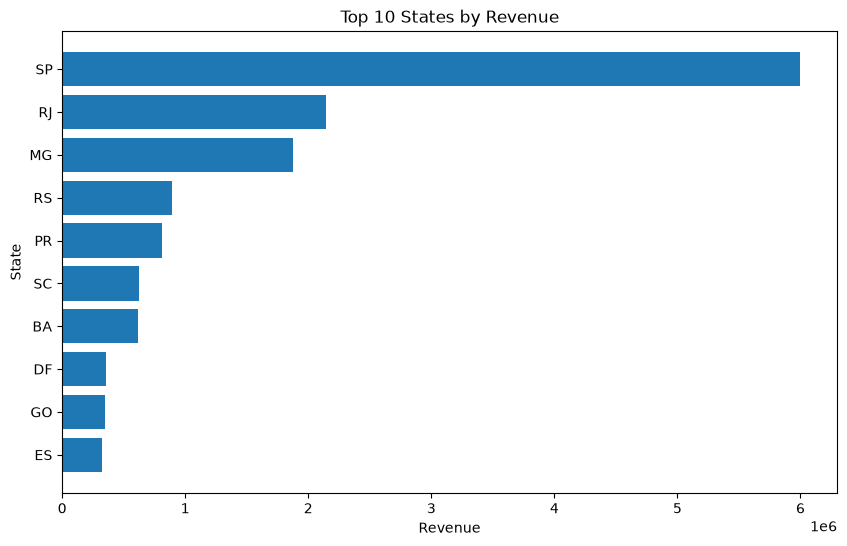

In [32]:
# visualize revenue by state
top10_states = state_revenue.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10_states["customer_state"],
    top10_states["payment_value"]
)
plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.savefig('../visuals/top10_states_revenue.png')
plt.show()

In [33]:
# customer count by state
state_customers = (
    geo_df
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
state_customers.head(10)

,customer_state,customer_unique_id
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


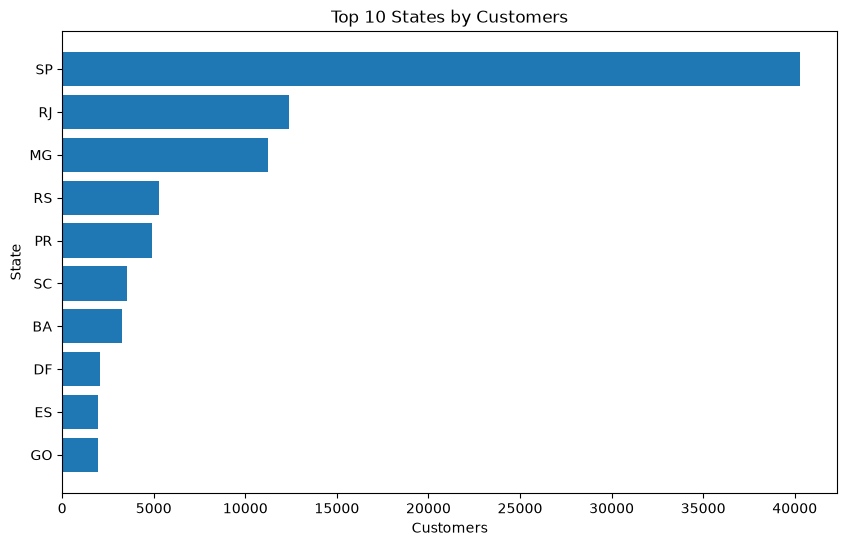

In [34]:
# visualize customer count
plt.figure(figsize=(10,6))
plt.barh(
    state_customers.head(10)["customer_state"],
    state_customers.head(10)["customer_unique_id"]
)
plt.title("Top 10 States by Customers")
plt.xlabel("Customers")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.savefig('../visuals/top10_states_by_customer.png')
plt.show()

In [35]:
# revenue per customer
state_summary = (
    geo_df
    .groupby("customer_state")
    .agg({
        "payment_value":"sum",
        "customer_unique_id":"nunique"
    })
    .reset_index()
)
state_summary["revenue_per_customer"] = (
    state_summary["payment_value"]
    / state_summary["customer_unique_id"]
)
state_summary.sort_values(
    by="revenue_per_customer",
    ascending=False
).head(10)

,customer_state,payment_value,customer_unique_id,revenue_per_customer
14,PB,141545.72,519,272.727784
0,AC,19680.62,77,255.592468
20,RO,60866.20,240,253.609167
3,AP,16262.80,67,242.728358
1,AL,96962.06,401,241.800648
13,PA,218295.85,949,230.027239
26,TO,61485.33,273,225.220989
16,PI,108523.97,482,225.153465
21,RR,10064.62,45,223.658222
24,SE,75246.25,342,220.018275


In [36]:
state_revenue.head(10)
state_customers.head(10)
state_summary.sort_values(
    by="revenue_per_customer",
    ascending=False
).head(10)

,customer_state,payment_value,customer_unique_id,revenue_per_customer
14,PB,141545.72,519,272.727784
0,AC,19680.62,77,255.592468
20,RO,60866.20,240,253.609167
3,AP,16262.80,67,242.728358
1,AL,96962.06,401,241.800648
13,PA,218295.85,949,230.027239
26,TO,61485.33,273,225.220989
16,PI,108523.97,482,225.153465
21,RR,10064.62,45,223.658222
24,SE,75246.25,342,220.018275


In [37]:
state_revenue.head(10)

,customer_state,payment_value
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


In [38]:
state_customers.head(10)

,customer_state,customer_unique_id
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


### Geographical_Analysis_Insights

- Sao Paulo (SP) is the platform's most important market, generating approximately 6 million in revenue and accounting for the largest customer base(40,302 Customers) which is more than 3 times the customer base of the next largest state, making it the primary driver of business performance.

- Regions with larger customer bases consistently generate higher revenue, suggesting that business growth is largely driven by customer acquisition rather than significantly higher spending per customer.

- Revenue is highly concentrated geographically, with Sao Paulo, Rio de Janeiro, and Minas Gerais contributing approximately 64% of total revenue. This indicates a strong dependence on a small number of regional markets.

- Although smaller states contribute less total revenue, several regions such as Paraíba, Acre, and Rondônia exhibit higher revenue per customer. This suggests stronger average spending behavior among customers in these markets.

### Cross_Analysis_Insight
- Revenue growth throughout 2017 and 2018 was primarily driven by acquiring new customers, particularly in major states such as São Paulo, Rio de Janeiro, and Minas Gerais. Given that only 3.12% of customers made repeat purchases, business expansion appears to rely more heavily on customer acquisition than customer retention.

## Key Business Recommendations

- Improve customer retention: Only 3.12% of customers made repeat purchases, indicating a strong opportunity to increase customer loyalty through personalized offers and retention campaigns.

- Invest in top-performing categories: Bed Bath Table and Health Beauty generated both high sales volume and revenue, making them key categories for future growth.

- Focus on core revenue drivers: The top 10 product categories contributed 63.16% of total revenue, highlighting the importance of prioritizing these categories in marketing and inventory planning.

- Expand beyond major markets: Around 64% of revenue came from São Paulo, Rio de Janeiro, and Minas Gerais, suggesting a need to diversify growth across other regions.

- Target high-spending states: States such as Paraíba, Acre, and Rondônia showed the highest revenue per customer and may offer attractive expansion opportunities.

- Leverage seasonal demand: Revenue and order volume peaked in November 2017, emphasizing the importance of preparing for major shopping events such as Black Friday.
